In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


In [4]:
df = pd.read_csv("cleaned_netflix_data.csv")

print(df.head())
print(df.info())


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [6]:
# Convert duration to numeric
df["duration_num"] = df["duration"].astype(str).str.extract('(\d+)')
df["duration_num"] = pd.to_numeric(df["duration_num"], errors="coerce")
df["duration_num"].fillna(df["duration_num"].median(), inplace=True)


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\HP\AppData\Local\Temp\ipykernel_18180\3523749343.py:2: SyntaxWarning: invalid escape sequence '\d'
  df["duration_num"] = df["duration"].astype(str).str.extract('(\d+)')
C:\Users\HP\AppData\Local\Temp\ipykernel_18180\3523749343.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.o

0        90.0
1         2.0
2         1.0
3         1.0
4         2.0
        ...  
8792    158.0
8793      2.0
8794     88.0
8795     88.0
8796    111.0
Name: duration_num, Length: 8797, dtype: float64

In [7]:
# Select important columns
features = [
    "release_year",
    "duration_num",
    "rating",
    "country",
    "listed_in"
]

data = df[features].copy()


In [8]:
# Fill missing values
data["country"].fillna("Unknown", inplace=True)
data["rating"].fillna("Unknown", inplace=True)
data["listed_in"].fillna("Unknown", inplace=True)

# One Hot Encoding
data = pd.get_dummies(data)

# Replace numeric NaN with median
for col in data.columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

# Scale Features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

print("Data Prepared Successfully!")

C:\Users\HP\AppData\Local\Temp\ipykernel_18180\488150946.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data["country"].fillna("Unknown", inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_18180\488150946.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an

Data Prepared Successfully!


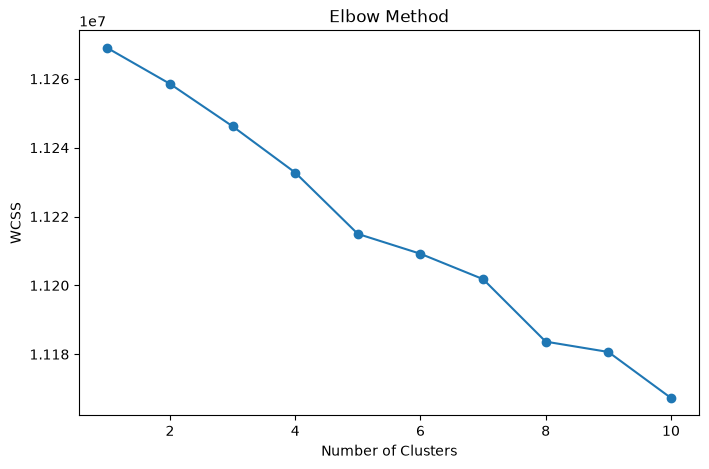

In [9]:
# K-Means Clustering

wcss = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_data)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.savefig("elbow_method.png")
plt.show()

# Best K = 4
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

df["Cluster"]  = clusters

# Save cluster labels
df["Cluster"] = clusters



In [10]:
# Cluster Summary

print("\n===== Cluster Summary =====")

for cluster in sorted(df["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    cluster_data = df[df["Cluster"] == cluster]

    print("Content Type:")
    print(cluster_data["type"].value_counts())

    print("\nTop Countries:")
    print(cluster_data["country"].value_counts().head(5))

    print("\nTop Genres:")
    print(cluster_data["listed_in"].value_counts().head(5))

    print("-" * 50)




===== Cluster Summary =====

Cluster 0
Content Type:
type
TV Show    1884
Movie       412
Name: count, dtype: int64

Top Countries:
country
Unknown           540
United States     415
Japan             218
South Korea       160
United Kingdom     90
Name: count, dtype: int64

Top Genres:
listed_in
Kids' TV                                             219
Children & Family Movies                             166
International TV Shows, TV Dramas                    121
Crime TV Shows, International TV Shows, TV Dramas    110
Kids' TV, TV Comedies                                 98
Name: count, dtype: int64
--------------------------------------------------

Cluster 1
Content Type:
type
TV Show    1
Name: count, dtype: int64

Top Countries:
country
United Kingdom, United States, Czech Republic    1
Name: count, dtype: int64

Top Genres:
listed_in
British TV Shows, Docuseries, Science & Nature TV    1
Name: count, dtype: int64
--------------------------------------------------

Cluster 2
Co

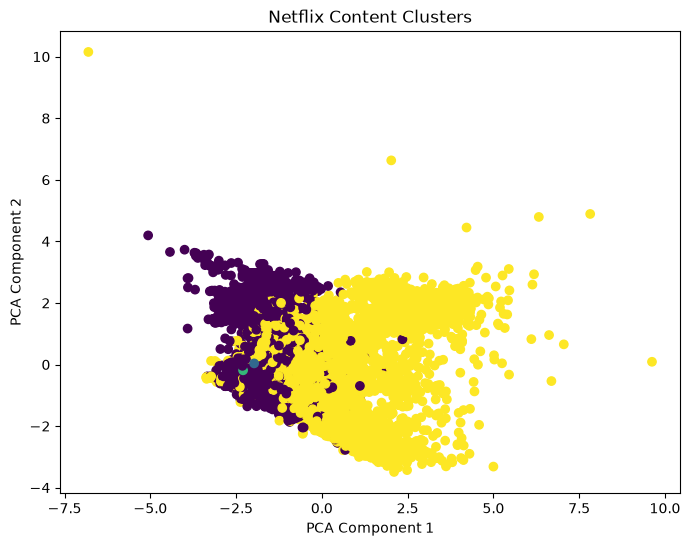

In [11]:
# PCA Visualization


pca = PCA(n_components=2)

components = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("Netflix Content Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.savefig("clusters_pca.png")
plt.show()



Accuracy
0.9988636363636364

Classification Report
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1229
     TV Show       1.00      1.00      1.00       531

    accuracy                           1.00      1760
   macro avg       1.00      1.00      1.00      1760
weighted avg       1.00      1.00      1.00      1760


Confusion Matrix
[[1227    2]
 [   0  531]]


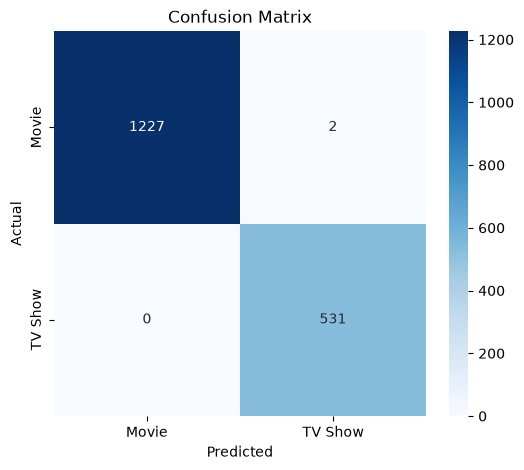

In [12]:
# Classification
# Predict Movie vs TV Show

target = df["type"]

X = data

y = target

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("\nAccuracy")
print(accuracy_score(y_test,pred))

print("\nClassification Report")
print(classification_report(y_test,pred))

print("\nConfusion Matrix")
cm = confusion_matrix(y_test,pred)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")
plt.show()


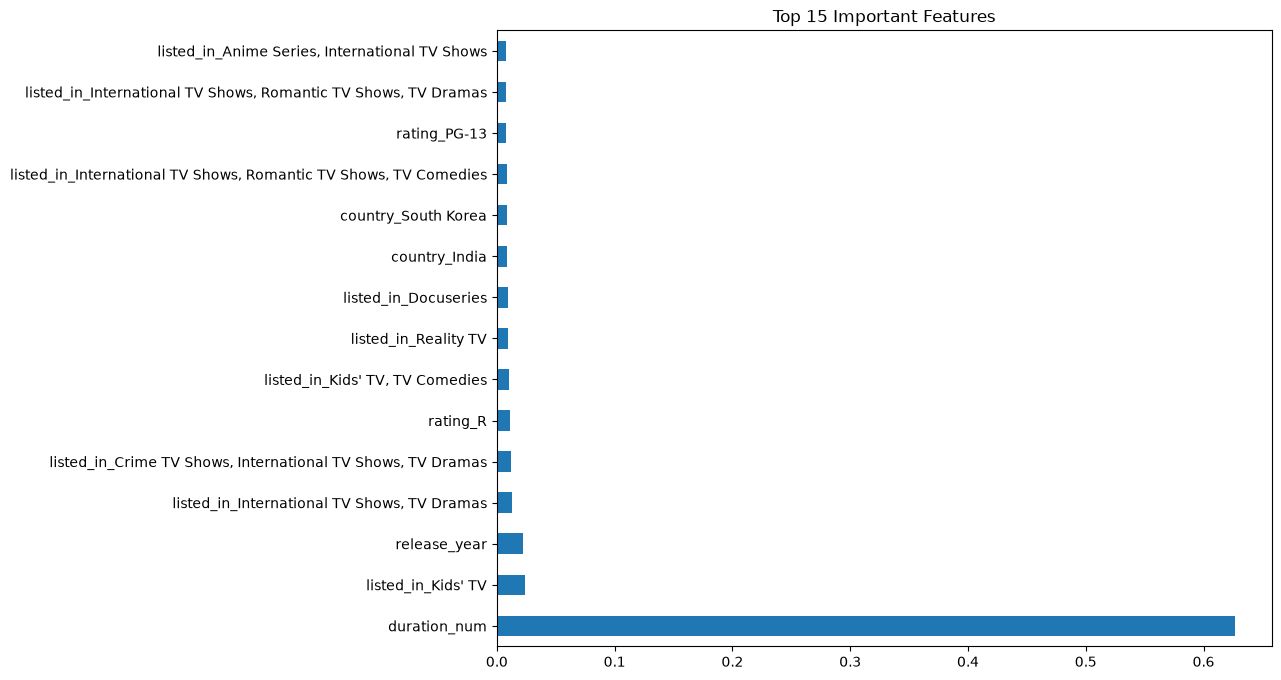


Top Important Features
duration_num                                                        0.626677
listed_in_Kids' TV                                                  0.024012
release_year                                                        0.021876
listed_in_International TV Shows, TV Dramas                         0.013229
listed_in_Crime TV Shows, International TV Shows, TV Dramas         0.011764
rating_R                                                            0.011126
listed_in_Kids' TV, TV Comedies                                     0.009908
listed_in_Reality TV                                                0.009801
listed_in_Docuseries                                                0.009101
country_India                                                       0.008991
country_South Korea                                                 0.008786
listed_in_International TV Shows, Romantic TV Shows, TV Comedies    0.008260
rating_PG-13                                        

In [13]:
# Feature Importance

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(15).plot(kind="barh")

plt.title("Top 15 Important Features")

plt.savefig("feature_importance.png")

plt.show()

print("\nTop Important Features")
print(importance.head(15))


In [14]:
# Save Final Dataset

df.to_csv(
    "netflix_milestone3_output.csv",
    index=False
)

print("\nMilestone 3 Completed Successfully!")


Milestone 3 Completed Successfully!
